[*********************100%***********************]  1 of 1 completed


  交易记录
                  price action          cash  shares         total
date                                                              
2024-11-11  2958.530518    BUY  1.668506e+01     338  1.000000e+06
2025-01-10  3217.091309   SELL  1.087394e+06       0  1.087394e+06
2025-01-28  3338.416016    BUY  2.408342e+03     325  1.087394e+06

  绩效摘要
  初始资金       : ¥   1,000,000
  最终资产       : ¥   1,210,856
  策略收益率     : +21.1%
  买入持有收益率 : +33.2%
  超额收益       : -12.1%


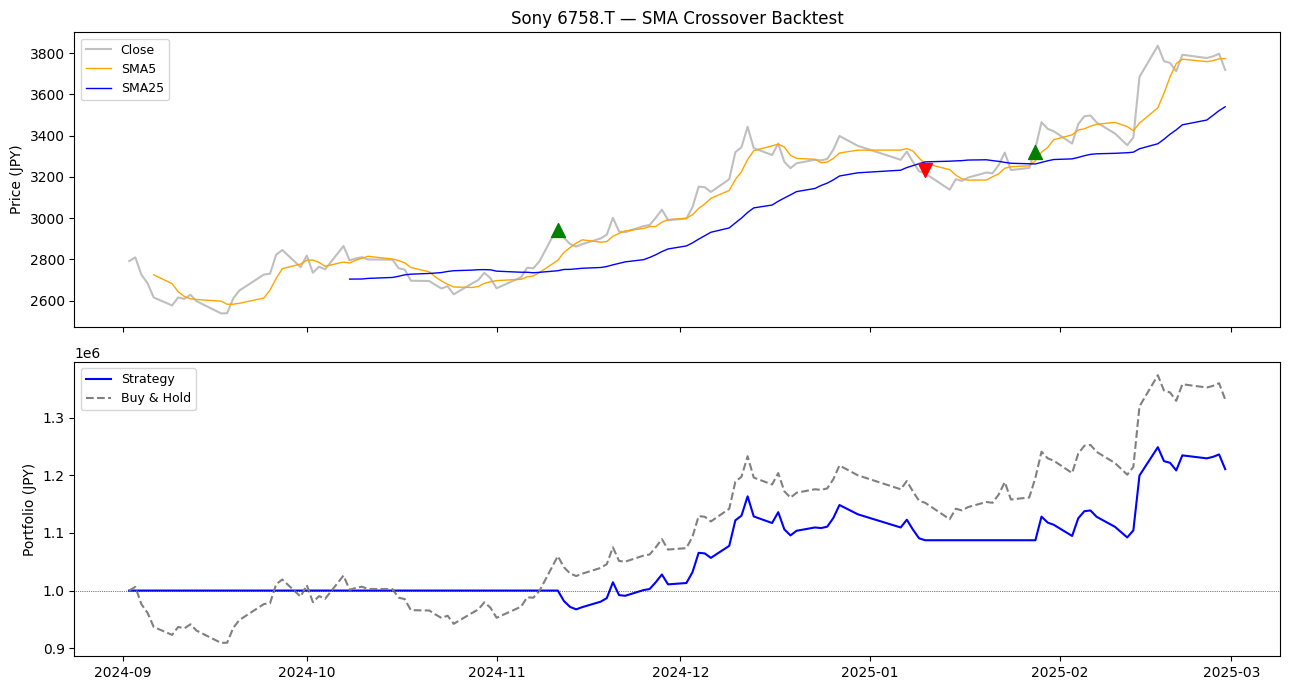

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. 数据准备 ────────────────────────────────────
df = yf.download("6758.T", start="2024-09-01", end="2025-03-01")
df.columns = df.columns.droplevel(1) if df.columns.nlevels > 1 else df.columns
df.dropna(inplace=True)

df["SMA5"]  = df["Close"].rolling(5).mean()
df["SMA25"] = df["Close"].rolling(25).mean()

prev = df["SMA5"].shift(1) - df["SMA25"].shift(1)
curr = df["SMA5"] - df["SMA25"]
df["signal"] = 0
df.loc[(prev < 0) & (curr > 0), "signal"] = 1   # 金叉 → 买入
df.loc[(prev > 0) & (curr < 0), "signal"] = -1  # 死叉 → 卖出

# ── 2. 回测引擎 ────────────────────────────────────
INITIAL_CASH = 1_000_000   # 初始资金 100万日元
cash         = INITIAL_CASH
shares       = 0
position     = False       # 是否持仓

records = []  # 记录每天状态

for date, row in df.iterrows():
    price = float(row["Close"])
    sig   = int(row["signal"])

    # 买入：金叉 且 没有持仓
    if sig == 1 and not position:
        shares   = int(cash / price)   # 买入尽可能多的股数
        cash    -= shares * price
        position = True
        action   = "BUY"

    # 卖出：死叉 且 有持仓
    elif sig == -1 and position:
        cash    += shares * price
        shares   = 0
        position = False
        action   = "SELL"

    else:
        action = "-"

    # 当日总资产 = 现金 + 持仓市值
    total = cash + shares * price
    records.append({
        "date"   : date,
        "price"  : price,
        "action" : action,
        "cash"   : cash,
        "shares" : shares,
        "total"  : total,
    })

result = pd.DataFrame(records).set_index("date")

# ── 3. 打印交易记录 ────────────────────────────────
trades = result[result["action"] != "-"]
print("=" * 55)
print("  交易记录")
print("=" * 55)
print(trades[["price", "action", "cash", "shares", "total"]].to_string())

# ── 4. 绩效摘要 ────────────────────────────────────
final_total   = result["total"].iloc[-1]
strategy_ret  = (final_total / INITIAL_CASH - 1) * 100

# 买入持有基准（Buy & Hold）
buyhold_ret   = (df["Close"].iloc[-1] / df["Close"].iloc[0] - 1) * 100

print("\n" + "=" * 55)
print("  绩效摘要")
print("=" * 55)
print(f"  初始资金       : ¥{INITIAL_CASH:>12,.0f}")
print(f"  最终资产       : ¥{final_total:>12,.0f}")
print(f"  策略收益率     : {strategy_ret:>+.1f}%")
print(f"  买入持有收益率 : {buyhold_ret:>+.1f}%")
print(f"  超额收益       : {strategy_ret - buyhold_ret:>+.1f}%")
print("=" * 55)

# ── 5. 资产曲线可视化 ──────────────────────────────
buyhold_curve = INITIAL_CASH * (df["Close"] / df["Close"].iloc[0])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# 上图：股价 + 买卖信号
ax1.plot(df["Close"], color="gray", alpha=0.5, label="Close")
ax1.plot(df["SMA5"],  color="orange", linewidth=1, label="SMA5")
ax1.plot(df["SMA25"], color="blue",   linewidth=1, label="SMA25")
buys  = result[result["action"] == "BUY"]
sells = result[result["action"] == "SELL"]
ax1.scatter(buys.index,  buys["price"]  * 0.995, marker="^", color="green", s=100, zorder=5)
ax1.scatter(sells.index, sells["price"] * 1.005, marker="v", color="red",   s=100, zorder=5)
ax1.set_ylabel("Price (JPY)")
ax1.legend(loc="upper left", fontsize=9)
ax1.set_title("Sony 6758.T — SMA Crossover Backtest")

# 下图：资产曲线对比
ax2.plot(result.index, result["total"],   color="blue",  linewidth=1.5, label="Strategy")
ax2.plot(buyhold_curve.index, buyhold_curve, color="gray", linewidth=1.5,
         linestyle="dashed", label="Buy & Hold")
ax2.axhline(INITIAL_CASH, color="black", linewidth=0.5, linestyle="dotted")
ax2.set_ylabel("Portfolio (JPY)")
ax2.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()